# Healthcare Provider Fraud Detection
End-to-end EDA → feature engineering → two-stage cascade model → evaluation.
All training data comes from `Train_*` files via stratified cross-validation.
Test files are ignored — they carry no labels.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier

from src.loaders import load_all
from src.features import enrich_claims, compute_cross_entity_spans, aggregate_to_provider

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
PARQUET = Path('../outputs/features_train.parquet')
RNG = 42

## 1 · Load raw data & verify encoding fixes
Assert every known encoding trap is handled before any analysis proceeds.

In [2]:
data = load_all()
bene, ip, op, labels = data['bene'], data['ip'], data['op'], data['labels']

cc_cols = [c for c in bene.columns if c.startswith('ChronicCond_')]

# --- assertions ---
# 1. RenalDiseaseIndicator is 0/1 int, no 'Y' strings
assert bene['RenalDiseaseIndicator'].isin([0, 1]).all(), 'RenalDiseaseIndicator not binary'

# 2. ChronicCond_* are 0/1 (original 2=No already remapped)
assert set(bene[cc_cols].stack().unique()).issubset({0, 1}), 'ChronicCond_* still has 2s'

# 3. DOD 'NA' strings become NaT
assert bene['DOD'].dtype == 'datetime64[ns]', 'DOD not parsed as datetime'

# 4. State and County are strings, not ints
assert bene['State'].dtype == object, 'State should be str, not ordinal int'

# 5. IDs loaded as str
assert ip['ClaimID'].dtype == object, 'ClaimID should be str'
assert ip['Provider'].dtype == object, 'Provider should be str'

# 6. Date columns are datetime
assert pd.api.types.is_datetime64_any_dtype(ip['ClaimStartDt']), 'ClaimStartDt not datetime'

print('All encoding assertions passed.')
print(f'  bene: {bene.shape}  ip: {ip.shape}  op: {op.shape}  labels: {labels.shape}')
print(f'  ChronicCond_* columns ({len(cc_cols)}): {cc_cols}')

All encoding assertions passed.
  bene: (138556, 25)  ip: (40474, 30)  op: (517737, 27)  labels: (5410, 2)
  ChronicCond_* columns (11): ['ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke']


## 2 · Class balance
**Question:** How imbalanced is the target, and what does that imply for metric choice?

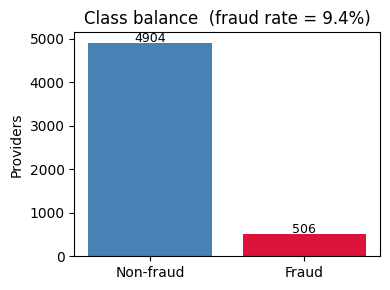

fraud_label
0    4904
1     506


In [3]:
fraud_counts = labels['fraud_label'].value_counts().sort_index()
fraud_rate   = labels['fraud_label'].mean()

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Non-fraud', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_ylabel('Providers')
ax.set_title(f'Class balance  (fraud rate = {fraud_rate:.1%})')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'class_balance.png', dpi=150)
plt.show()
print(fraud_counts.to_string())

**Takeaway:** ~9.35 % fraud rate. Accuracy is meaningless here — a model that predicts "no fraud" for everyone scores 90 %. We report PR-AUC as the primary metric.

## 3 · Fraud vs non-fraud provider profiles
**Question:** Do fraudulent providers differ on volume, beneficiaries, money, and physician counts?

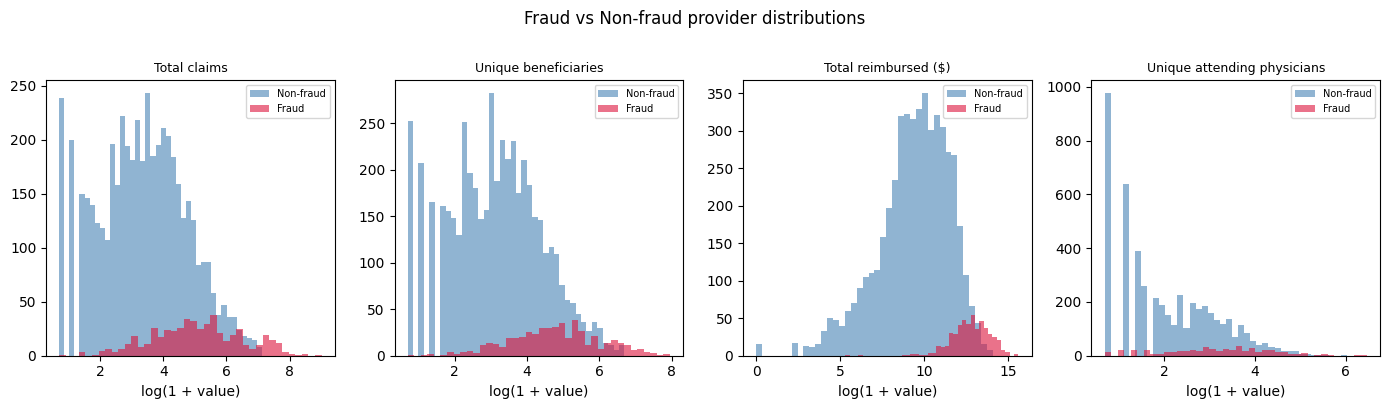

In [4]:
# Quick provider-level stats using raw claim counts before full feature engineering
ip['_type'] = 'ip'
op['_type'] = 'op'
all_raw = pd.concat([ip[['Provider','BeneID','ClaimID','InscClaimAmtReimbursed',
                          'AttendingPhysician','_type']],
                     op[['Provider','BeneID','ClaimID','InscClaimAmtReimbursed',
                          'AttendingPhysician','_type']]], ignore_index=True)

quick = all_raw.groupby('Provider').agg(
    n_claims=('ClaimID','count'),
    n_bene=('BeneID','nunique'),
    total_reimb=('InscClaimAmtReimbursed','sum'),
    n_physicians=('AttendingPhysician','nunique'),
).reset_index().merge(labels, on='Provider')

metrics = ['n_claims','n_bene','total_reimb','n_physicians']
labels_txt = ['Total claims','Unique beneficiaries','Total reimbursed ($)','Unique attending physicians']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col, lbl in zip(axes, metrics, labels_txt):
    for val, color, name in [(0,'steelblue','Non-fraud'),(1,'crimson','Fraud')]:
        subset = quick.loc[quick['fraud_label']==val, col]
        ax.hist(np.log1p(subset), bins=40, alpha=0.6, color=color, label=name)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('log(1 + value)')
    ax.legend(fontsize=7)
plt.suptitle('Fraud vs Non-fraud provider distributions', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'fraud_vs_nonfraud_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Takeaway:** Fraudulent providers systematically show higher claim volumes, more beneficiaries, higher total reimbursements, and more attending physicians — but distributions overlap heavily, so volume alone is not a clean separator.

## 4 · Does claim volume alone separate the classes?
**Question:** Is a simple threshold on claim count enough, or does the model need deeper signal?

In [5]:
from sklearn.metrics import average_precision_score as aps

# Rank by raw claim count — how good is this naive ranker?
vol_score = (quick['n_claims'] - quick['n_claims'].min()) / (quick['n_claims'].max() - quick['n_claims'].min())
vol_prauc  = aps(quick['fraud_label'], vol_score)
print(f'PR-AUC using only claim count as score: {vol_prauc:.3f}')
print('(Random baseline = fraud rate ≈ 0.093)')
print()
# Recall at top-100 and top-500 by claim volume
ranked = quick.sort_values('n_claims', ascending=False)
for k in [100, 500]:
    r = ranked.head(k)['fraud_label'].sum() / labels['fraud_label'].sum()
    print(f'Recall@{k} (by claim count): {r:.2f}')

PR-AUC using only claim count as score: 0.400
(Random baseline = fraud rate ≈ 0.093)

Recall@100 (by claim count): 0.14
Recall@500 (by claim count): 0.38


**Takeaway:** Volume is a real signal but far from perfect. The ablation later will quantify how much PR-AUC is volume vs. richer features.

## 5 · Missingness
**Question:** Which fields have meaningful gaps that could bias features?

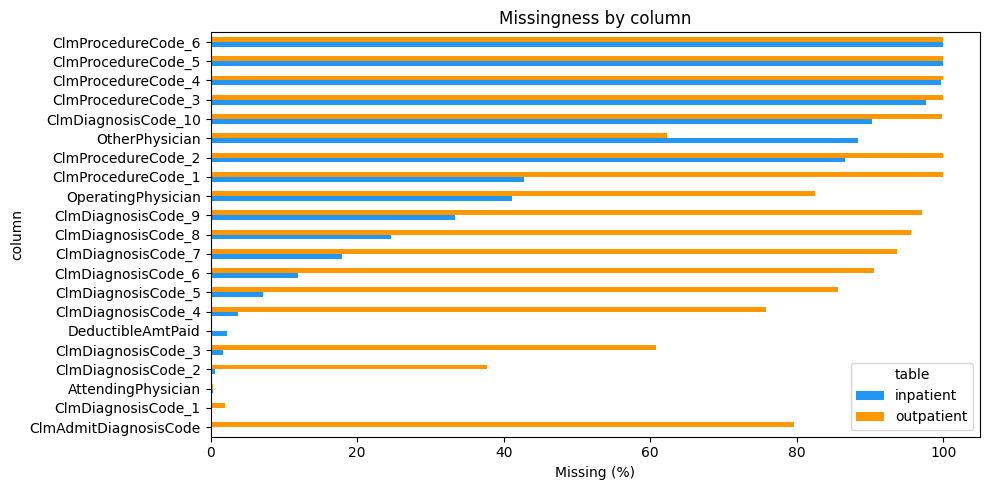

               column   miss_pct      table
   ClmProcedureCode_6 100.000000  inpatient
   ClmProcedureCode_5  99.977764  inpatient
   ClmProcedureCode_4  99.713396  inpatient
   ClmProcedureCode_3  97.615753  inpatient
  ClmDiagnosisCode_10  90.297475  inpatient
       OtherPhysician  88.412314  inpatient
   ClmProcedureCode_2  86.524683  inpatient
   ClmProcedureCode_1  42.807728  inpatient
   OperatingPhysician  41.122696  inpatient
   ClmDiagnosisCode_9  33.347334  inpatient
   ClmDiagnosisCode_8  24.563918  inpatient
   ClmDiagnosisCode_7  17.932500  inpatient
   ClmDiagnosisCode_6  11.953353  inpatient
   ClmDiagnosisCode_5   7.150269  inpatient
   ClmDiagnosisCode_4   3.790087  inpatient
    DeductibleAmtPaid   2.221179  inpatient
   ClmDiagnosisCode_3   1.670208  inpatient
   ClmDiagnosisCode_2   0.558383  inpatient
   AttendingPhysician   0.276721  inpatient
   ClmProcedureCode_6 100.000000 outpatient
   ClmProcedureCode_5 100.000000 outpatient
   ClmProcedureCode_4  99.999614

In [6]:
def missingness_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    pct = df.isna().mean().mul(100).rename('miss_pct')
    return pct[pct > 0].sort_values(ascending=False).rename_axis('column').reset_index().assign(table=name)

miss = pd.concat([missingness_report(ip, 'inpatient'), missingness_report(op, 'outpatient')], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
pivot = miss.pivot(index='column', columns='table', values='miss_pct').fillna(0)
pivot.sort_values('inpatient', ascending=True).plot.barh(ax=ax, color=['#2196F3','#FF9800'])
ax.set_xlabel('Missing (%)')
ax.set_title('Missingness by column')
plt.tight_layout()
plt.savefig(FIGURES / 'missingness.png', dpi=150)
plt.show()
print(miss.to_string(index=False))

**Takeaway:** Procedure codes and `OperatingPhysician`/`OtherPhysician` are mostly missing — use nunique counts not fill-values. `AttendingPhysician` is nearly complete; its absence is itself a fraud signal.

## 6 · Cross-entity ring signals
**Question:** Do any physicians or beneficiaries appear across unusually many providers — a hallmark of billing rings?

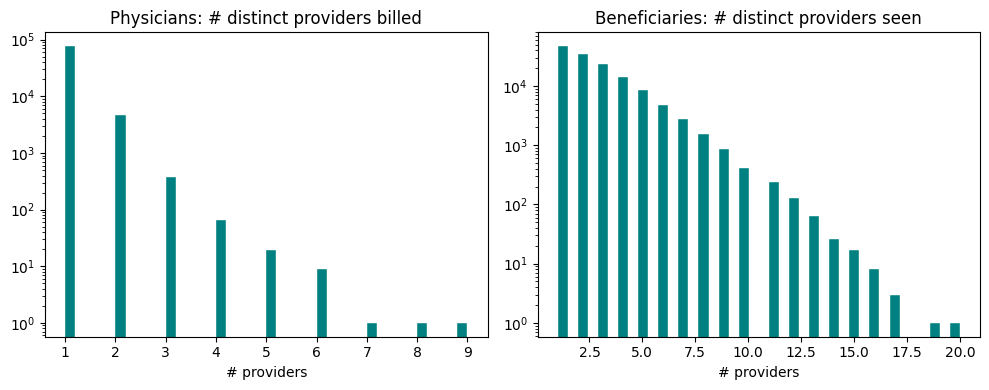

Physicians billing ≥5 providers: 31
Beneficiaries seen at ≥5 providers: 19244


In [7]:
phy_multi = (
    all_raw.dropna(subset=['AttendingPhysician'])
    .groupby('AttendingPhysician')['Provider'].nunique()
    .sort_values(ascending=False)
)
bene_multi = (
    all_raw.groupby('BeneID')['Provider'].nunique()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, series, title in zip(axes,
    [phy_multi, bene_multi],
    ['Physicians: # distinct providers billed', 'Beneficiaries: # distinct providers seen']):
    ax.hist(series.values, bins=40, color='teal', edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_xlabel('# providers')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIGURES / 'cross_entity_rings.png', dpi=150)
plt.show()
print(f'Physicians billing ≥5 providers: {(phy_multi>=5).sum()}')
print(f'Beneficiaries seen at ≥5 providers: {(bene_multi>=5).sum()}')

**Takeaway:** A small number of physicians bill through many distinct providers and a tail of beneficiaries appear at many clinics — both are ring indicators that become per-provider mean features.

## 7 · Feature engineering
Enrich claims, compute cross-entity spans, then aggregate to one row per provider.

In [8]:
if PARQUET.exists():
    provider_df = pd.read_parquet(PARQUET)
    print(f'Loaded cached features: {provider_df.shape}')
else:
    ip_enr = enrich_claims(ip.drop(columns=['_type'], errors='ignore'), bene, is_inpatient=True)
    op_enr = enrich_claims(op.drop(columns=['_type'], errors='ignore'), bene, is_inpatient=False)

    # Tag before concat so re-split is unambiguous even if ClaimIDs overlap
    ip_enr['_src'] = 'ip'
    op_enr['_src'] = 'op'

    # Cross-entity spans computed over full dataset (mild known leak — all folds see all providers)
    all_enr = compute_cross_entity_spans(pd.concat([ip_enr, op_enr], ignore_index=True))

    ip_span = all_enr[all_enr['_src'] == 'ip'].drop(columns=['_src'])
    op_span = all_enr[all_enr['_src'] == 'op'].drop(columns=['_src'])

    provider_df = aggregate_to_provider(ip_span, op_span)
    provider_df = provider_df.merge(labels, on='Provider', how='inner')
    provider_df.to_parquet(PARQUET, index=False)
    print(f'Built and cached features: {provider_df.shape}')

FEATURE_COLS = [c for c in provider_df.columns if c not in ('Provider', 'fraud_label')]
VOLUME_COLS  = ['n_claims', 'n_inpatient_claims', 'n_outpatient_claims', 'n_unique_bene']
print(f'Feature count: {len(FEATURE_COLS)}')

Built and cached features: (5410, 33)
Feature count: 31


## 8 · Two-stage cascade model
**Stage 1 — RandomForest high-recall gate:** tune threshold to retain ~95% of positives, eliminating a fraction of clear negatives.
**Stage 2 — XGBoost on survivors:** uses `scale_pos_weight` from the actual class ratio.

> **Note on cross-entity leak:** `phy_n_providers` and `bene_n_providers` are computed over the full training set, so each CV fold's test split has seen those statistics during span computation. This is a mild, known leak we flag here rather than hide — fixing it fully would require per-fold recomputation at substantial cost.

In [9]:
def run_pipeline(feature_cols, label='all features'):
    """Two-stage cascade with StratifiedKFold CV. Returns OOF predictions."""
    X = provider_df[feature_cols].fillna(0).values
    y = provider_df['fraud_label'].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

    pos_rate = y.mean()
    scale_pw  = (1 - pos_rate) / pos_rate
    oof_proba = np.zeros(len(y))

    for fold, (tr, te) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        # Stage 1: Random Forest gate (OOB probabilities avoid in-sample memorization)
        rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    oob_score=True, n_jobs=-1, random_state=RNG)
        rf.fit(X_tr, y_tr)

        # Use OOB decision function so threshold is calibrated on held-out leaves
        oob_proba_tr = rf.oob_decision_function_[:, 1]
        rf_proba_te  = rf.predict_proba(X_te)[:, 1]

        # Gate threshold = 5th percentile of OOB scores among training positives
        # → designed to pass ~95% of positives through to Stage 2
        pos_oob = oob_proba_tr[y_tr == 1]
        gate_thresh = np.percentile(pos_oob, 5) if len(pos_oob) > 0 else 0.0

        survivors_tr = oob_proba_tr >= gate_thresh
        survivors_te = rf_proba_te  >= gate_thresh

        # Stage 2: XGBoost on survivors — require both classes in training subset
        has_both = (y_tr[survivors_tr].sum() > 0 and
                    (y_tr[survivors_tr] == 0).sum() > 0)
        if survivors_tr.sum() > 10 and has_both:
            xgb = XGBClassifier(
                n_estimators=400, max_depth=5, learning_rate=0.05,
                scale_pos_weight=scale_pw, eval_metric='aucpr',
                random_state=RNG, subsample=0.8, colsample_bytree=0.8,
                tree_method='hist', verbosity=0,
            )
            xgb.fit(X_tr[survivors_tr], y_tr[survivors_tr])
            if survivors_te.sum() > 0:
                oof_proba[te[survivors_te]] = xgb.predict_proba(X_te[survivors_te])[:, 1]

    eliminated       = (oof_proba == 0).sum()
    eliminated_fraud = ((oof_proba == 0) & (y == 1)).sum()
    print(f'[{label}] Gate eliminated {eliminated}/{len(y)} providers '
          f'({eliminated/len(y):.1%}); missed {eliminated_fraud} fraudsters')
    return oof_proba, y

In [10]:
print('Running pipeline with ALL features...')
oof_all, y_all = run_pipeline(FEATURE_COLS, 'all features')

vol_drop = [c for c in VOLUME_COLS if c in FEATURE_COLS]
reduced_cols = [c for c in FEATURE_COLS if c not in vol_drop]
print(f'\nRunning pipeline WITHOUT volume features ({vol_drop})...')
oof_nov, y_nov = run_pipeline(reduced_cols, 'no volume')

Running pipeline with ALL features...


[all features] Gate eliminated 3888/5410 providers (71.9%); missed 24 fraudsters

Running pipeline WITHOUT volume features (['n_claims', 'n_inpatient_claims', 'n_outpatient_claims', 'n_unique_bene'])...


[no volume] Gate eliminated 3972/5410 providers (73.4%); missed 28 fraudsters


## 9 · Evaluation
Primary metric: PR-AUC. Also ROC-AUC, Recall@100, Recall@500, and confusion matrix at chosen threshold.

In [11]:
def evaluate(proba, y, label):
    prauc = average_precision_score(y, proba)
    rocauc = roc_auc_score(y, proba)
    ranked_idx = np.argsort(proba)[::-1]
    r100 = y[ranked_idx[:100]].sum() / y.sum()
    r500 = y[ranked_idx[:500]].sum() / y.sum()
    print(f'{label}:')
    print(f'  PR-AUC  = {prauc:.4f}')
    print(f'  ROC-AUC = {rocauc:.4f}')
    print(f'  Recall@100 = {r100:.3f}    Recall@500 = {r500:.3f}')
    return prauc, rocauc, r100, r500

results_all = evaluate(oof_all, y_all, 'All features')
print()
results_nov = evaluate(oof_nov, y_nov, 'No volume features')
print()
delta = results_all[0] - results_nov[0]
print(f'PR-AUC delta (all vs no-volume): {delta:+.4f}')
if delta > 0.05:
    print('→ Volume features contribute substantially; model is partly a billing-volume ranker.')
elif delta > 0.01:
    print('→ Volume contributes modestly; meaningful signal exists beyond claim count.')
else:
    print('→ Model has strong signal beyond volume alone.')

All features:
  PR-AUC  = 0.7282
  ROC-AUC = 0.9419
  Recall@100 = 0.186    Recall@500 = 0.654

No volume features:
  PR-AUC  = 0.7304
  ROC-AUC = 0.9403
  Recall@100 = 0.188    Recall@500 = 0.656

PR-AUC delta (all vs no-volume): -0.0022
→ Model has strong signal beyond volume alone.


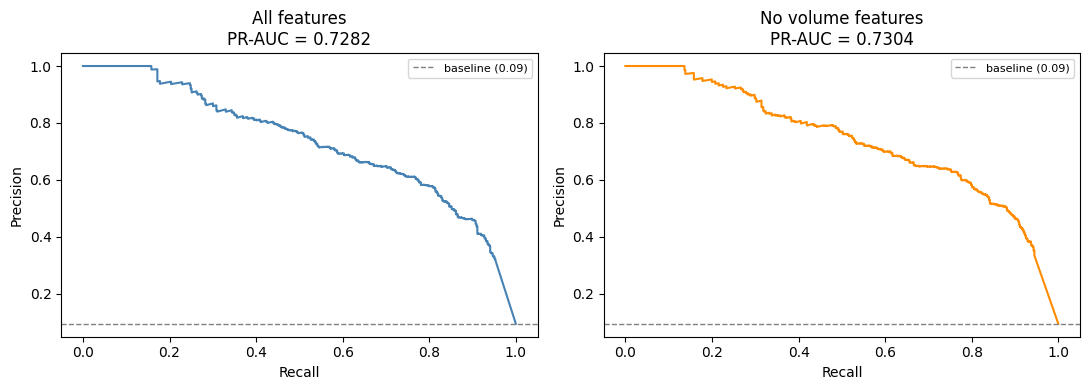

In [12]:
# PR curves (both runs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, proba, y, lbl, c in [
    (axes[0], oof_all, y_all, 'All features', 'steelblue'),
    (axes[1], oof_nov, y_nov, 'No volume features', 'darkorange')
]:
    prec, rec, _ = precision_recall_curve(y, proba)
    prauc = average_precision_score(y, proba)
    ax.plot(rec, prec, color=c, lw=1.5)
    ax.axhline(y.mean(), ls='--', color='grey', lw=1, label=f'baseline ({y.mean():.2f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{lbl}\nPR-AUC = {prauc:.4f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'pr_curves.png', dpi=150)
plt.show()

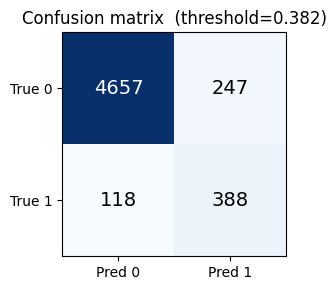

Threshold: 0.3816
Precision: 0.611  Recall: 0.767


In [13]:
# Confusion matrix at F1-optimal threshold (all-features run)
prec, rec, thresholds = precision_recall_curve(y_all, oof_all)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_thresh = thresholds[np.argmax(f1)]
preds = (oof_all >= best_thresh).astype(int)
cm = confusion_matrix(y_all, preds)

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['True 0','True 1'])
ax.set_title(f'Confusion matrix  (threshold={best_thresh:.3f})')
plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrix.png', dpi=150)
plt.show()
print(f'Threshold: {best_thresh:.4f}')
print(f'Precision: {cm[1,1]/(cm[0,1]+cm[1,1]+1e-9):.3f}  Recall: {cm[1,1]/(cm[1,0]+cm[1,1]+1e-9):.3f}')

## 10 · SHAP feature importance
Fit a single XGBoost model on the full training set (all features) for SHAP analysis.

In [14]:
X_full = provider_df[FEATURE_COLS].fillna(0)
y_full = provider_df['fraud_label'].values
pos_rate = y_full.mean()

final_xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    scale_pos_weight=(1-pos_rate)/pos_rate, eval_metric='aucpr',
    random_state=RNG, subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', verbosity=0,
)
final_xgb.fit(X_full, y_full)

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_full)
print('SHAP values computed.')

SHAP values computed.


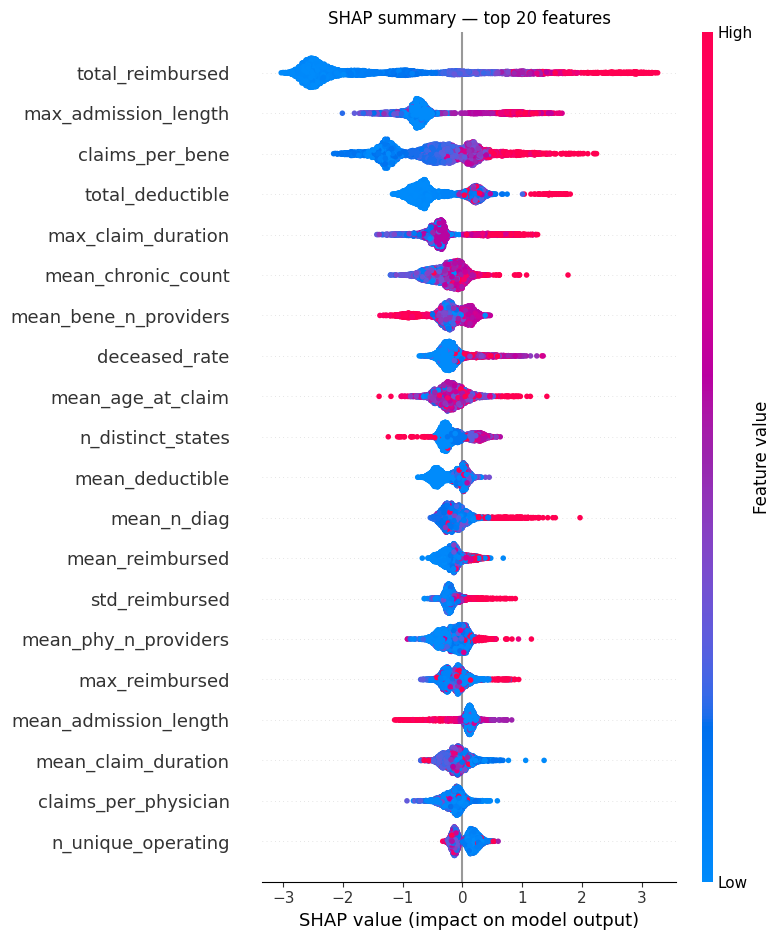

Top 10 features by mean |SHAP|:
total_reimbursed         1.9029
max_admission_length     0.7958
claims_per_bene          0.6904
total_deductible         0.5471
max_claim_duration       0.4848
mean_chronic_count       0.2808
mean_bene_n_providers    0.2674
deceased_rate            0.2491
mean_age_at_claim        0.2418
n_distinct_states        0.2411


In [15]:
# SHAP summary plot
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_full, feature_names=FEATURE_COLS,
                  max_display=20, show=False)
plt.title('SHAP summary — top 20 features')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 by mean |SHAP|
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS)
top10 = mean_abs_shap.sort_values(ascending=False).head(10)
print('Top 10 features by mean |SHAP|:')
print(top10.round(4).to_string())

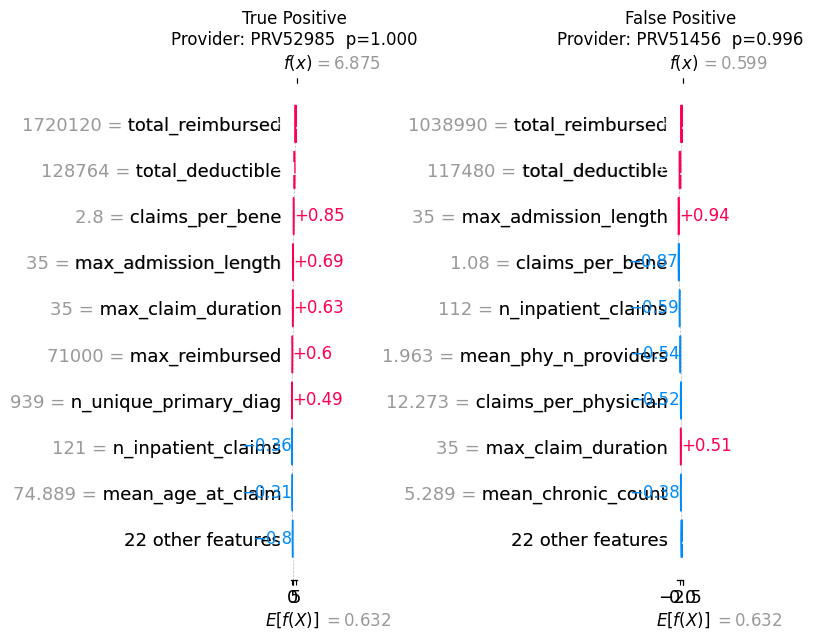

In [16]:
# Waterfall plots: one true positive, one false positive (by highest OOF probability)
provider_df_shap = provider_df.copy()
provider_df_shap['oof_proba'] = oof_all
provider_df_shap['shap_idx']  = range(len(provider_df_shap))

tp_candidates = provider_df_shap[provider_df_shap['fraud_label'] == 1].sort_values('oof_proba', ascending=False)
fp_candidates = provider_df_shap[provider_df_shap['fraud_label'] == 0].sort_values('oof_proba', ascending=False)
tp_row = tp_candidates.iloc[0]
fp_row = fp_candidates.iloc[0]

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_full.values,
    feature_names=FEATURE_COLS,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, row, title in [(axes[0], tp_row, 'True Positive'), (axes[1], fp_row, 'False Positive')]:
    plt.sca(ax)
    idx = int(row['shap_idx'])
    shap.waterfall_plot(shap_exp[idx], max_display=10, show=False)
    ax.set_title(f'{title}\nProvider: {row["Provider"]}  p={row["oof_proba"]:.3f}')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Expected-loss investigator ranking
**Question:** Which providers should an investigator prioritise — combining fraud probability with money at stake?

In [17]:
ranking = provider_df[['Provider','fraud_label','total_reimbursed']].copy()
ranking['oof_proba']       = oof_all
ranking['expected_loss']   = ranking['oof_proba'] * ranking['total_reimbursed']
ranking = ranking.sort_values('expected_loss', ascending=False).head(20).reset_index(drop=True)
ranking.index += 1  # 1-based rank

display_cols = ['Provider','fraud_label','oof_proba','total_reimbursed','expected_loss']
print('Top 20 providers by expected loss (probability × total reimbursed):')
print(ranking[display_cols].to_string(
    formatters={
        'oof_proba': '{:.3f}'.format,
        'total_reimbursed': '${:,.0f}'.format,
        'expected_loss': '${:,.0f}'.format,
    }
))

Top 20 providers by expected loss (probability × total reimbursed):
    Provider  fraud_label oof_proba total_reimbursed expected_loss
1   PRV52019            1     0.999       $5,996,050    $5,989,023
2   PRV55462            1     1.000       $4,713,830    $4,712,955
3   PRV56560            1     1.000       $3,212,000    $3,211,639
4   PRV54367            1     0.997       $3,133,880    $3,125,211
5   PRV54742            1     1.000       $2,969,530    $2,968,782
6   PRV55209            1     0.998       $2,914,700    $2,909,358
7   PRV53706            1     0.998       $2,831,940    $2,826,997
8   PRV56416            1     1.000       $2,744,870    $2,744,454
9   PRV55230            1     0.990       $2,612,740    $2,587,225
10  PRV52340            1     1.000       $2,540,130    $2,539,488
11  PRV57191            1     1.000       $2,424,430    $2,424,079
12  PRV51459            1     0.999       $2,321,890    $2,318,638
13  PRV55215            1     0.998       $2,284,560    $2,28

**Takeaway:** Expected-loss ranking surfaces high-risk, high-dollar providers. A pure probability rank could flag low-dollar outliers that are less cost-effective to investigate.